In [1]:
# Setup: imports and global configuration
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Use a consistent style for plots
# plt.style.use('seaborn-v0_8')

# Device selection
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Utilities: helper functions for analysis
from typing import Optional, Tuple

# Reuse helpers from src.utils
from src.utils.analysis import predict_all, tsne_scatter
import src.utils.analysis as analysis
import src.utils.interpretability as interp


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import matplotlib.pyplot as plt
import numpy as np 
set_seed(0) 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/reg_mixer_attnpl_t_20260204-161105") 
# checkpoints/reg_mixer_attnpl_t_20260131-114145
checkpoint_path = checkpoint_dir / "last_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model = torch.compile(model)
model.eval() 

Initializing MixerAdapter with stats: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
using extractor: attn_time_biased_mh time_bias_type: log extractor_config: {'fuse_mode': 'concat', 'use_ln': True, 'use_var_scale': True}
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'reg_mixer_attnpl_t', 'use_ema': False, 'batch_size': 64, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 0.01, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_

OptimizedModule(
  (_orig_mod): TaskModel(
    (base_model): MixerModelWrapper(
      (encoder): MixerModel(
        (input_proj): Sequential(
          (0): Tanh()
          (1): Linear(in_features=1, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0): Block(
            (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mixer): Mamba2Rotary(
              (in_proj): Linear(in_features=64, out_features=514, bias=False)
              (conv1d): Conv1d(384, 384, kernel_size=(4,), stride=(1,), padding=(3,), groups=384)
              (act): SiLU()
              (norm): RMSNorm()
              (out_proj): Linear(in_features=128, out_features=64, bias=False)
              (rotary_emb): RotaryEmbeddingTime()
            )
            (dropout): Dropout(p=0.1, inplace=False)
            (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mlp): GatedMLP(
              (f

In [4]:
from src.data.preparation import prepare_data
base_dir = f"../data/{args.dataset}"
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=base_dir, args=args,)

CSV files found: ['Chuandian2021.csv']
Catalog statistics: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
stas {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
[✔] Loading cached data from: ../data/ChuanDian/processed/regressor/regressor_Mc_3_Mf_3_Tfore_180_Twindow_360_context_le

In [5]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 

In [6]:
import src.data.event_loader as loader
args.batch_size =32
data_loader = loader.get_dataloader(catalog_ds, batch_size=args.batch_size, shuffle=False, task_type=args.task_type)

In [7]:
for x, y in test_loader:
    x, y = x.to(device), y.to(device)

In [8]:
model.base_model.input_adapter.mag_mean_gr

tensor(3.5069)

In [9]:
# model.base_model.input_adapter(x)['features'][0,:,0]
# odel.base_model.encoder.input_proj(model.base_model.input_adapter(x)['features'])[0,0,:]

In [10]:
mag = torch.linspace(3, 7.5, steps=x.shape[1], device=x.device).unsqueeze(0).expand(x.shape[0], -1)
x[:,:,2] = mag

/root/miniconda3/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


mean: 0.0006607489776797593
std : 0.0430402047932148
min : -0.1209554523229599
max : 0.12184396386146545


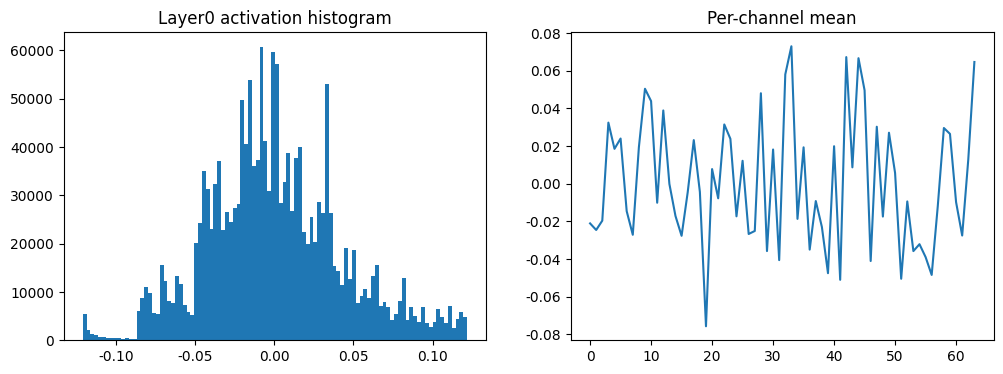

In [11]:
import matplotlib.pyplot as plt
# Capture activations after encoder layer[0]
layer0_out = []

def _hook(module, inp, out):
    # out may be tuple: (hidden_states, residual)
    if isinstance(out, tuple):
        out = out[0]

    layer0_out.append(out.detach().cpu())

# hook_handle = model.base_model.encoder.layers[0].register_forward_hook(_hook)
hook_handle = model.base_model.encoder.input_proj.register_forward_hook(_hook)

with torch.no_grad():
    _ = model(x)

hook_handle.remove()

# ===== visualize =====
if len(layer0_out) > 0:
    h = layer0_out[0]   # (B, L, D)

    # Global stats
    print("mean:", h.mean().item())
    print("std :", h.std().item())
    print("min :", h.min().item())
    print("max :", h.max().item())

    # Per-channel mean
    channel_means = h.mean(dim=(0, 1)).numpy()

    # Flatten histogram
    h_flat = h.reshape(-1).numpy()

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(h_flat, bins=100)
    plt.title("Layer0 activation histogram")

    plt.subplot(1,2,2)
    plt.plot(channel_means)
    plt.title("Per-channel mean")

    plt.show()
else:
    print("No activations captured.")

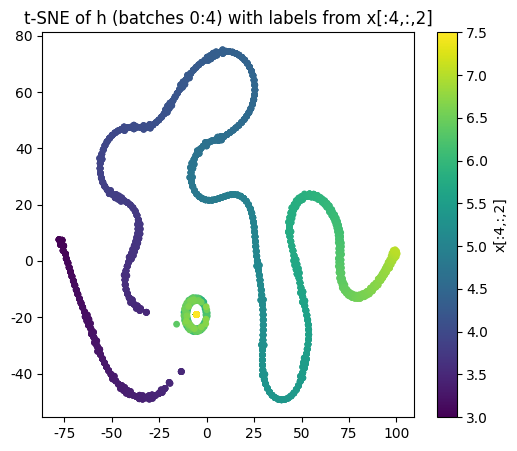

In [12]:
# t-SNE on pooled inputs with labels from batches 0:4
h_np = interp.to_numpy(h[:5]).reshape(-1, h.shape[-1])   # (4*L, D)
labels = interp.to_numpy(x[:5, :, 2]).reshape(-1)        # (4*L,)

X_emb = TSNE(n_components=2, random_state=42).fit_transform(h_np)

plt.figure(figsize=(6, 5))
sc = plt.scatter(X_emb[:, 0], X_emb[:, 1], c=labels, cmap="viridis", s=15)
plt.colorbar(sc, label="x[:4,:,2]")
plt.title("t-SNE of h (batches 0:4) with labels from x[:4,:,2]")
plt.show()

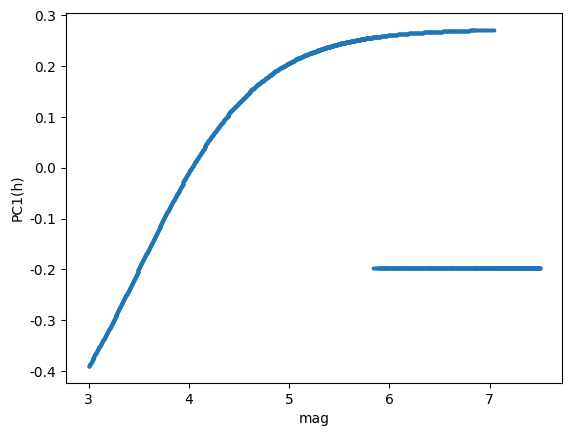

In [13]:
from sklearn.decomposition import PCA
pc1 = PCA(n_components=1).fit_transform(h_np)[:,0]
plt.scatter(labels, pc1, s=3)
plt.xlabel("mag")
plt.ylabel("PC1(h)")
plt.show()


In [ ]:
from src.utils.metrics import regression_metrics, log_metrics, plot_and_save_roc_curve
y_pred_val, y_val, X_val = analysis.predict_all(model,val_loader, device, return_X=True)

# start=0
# end =400
# regression_metrics(y_val[start:end], y_pred_val[start:end])  

{'RMSE': 0.15683927190979488,
 'MAE': 0.1286159776724302,
 'MSE': 0.024598557213194573,
 'MAPE': 29.121228579154735,
 'R2': -0.4813664174901493,
 'PearsonR': -0.055841533441214654,
 'PearsonR_diff': 0.07966911688891834,
 'DA': 0.049723756906077346,
 'SpearmanR': -0.07009264575487215,
 'SpearmanR_diff': 0.07375709622177248,
 'DTW': 17.522250771522522,
 'DTW_normalized': 0.09627610314023363}

In [15]:
X_all = X_val
y_all = y_val
y_pred_all = y_pred_val

/root/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


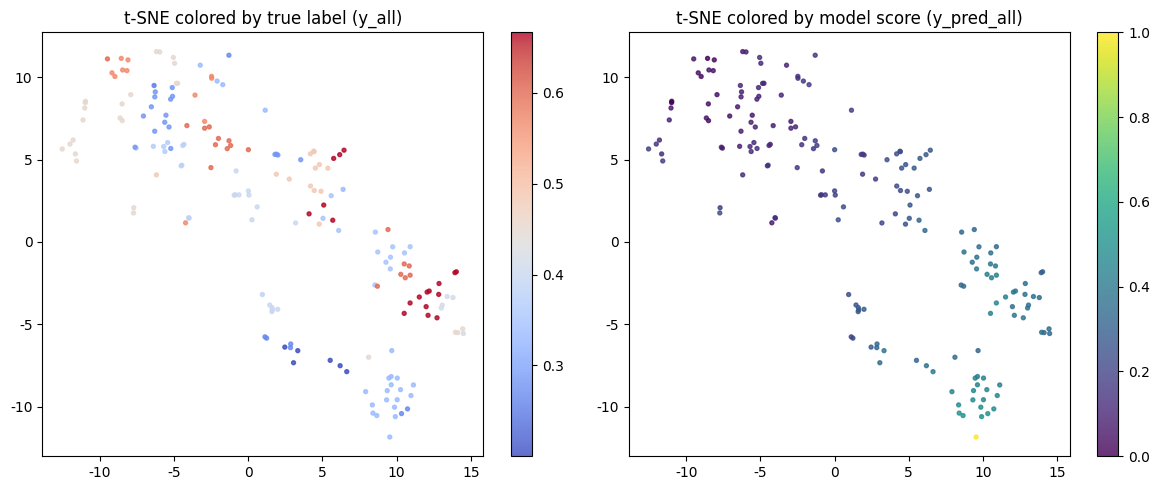

In [16]:
# t-SNE visualization of pooled features
X_scaled, X_tsne, y_score = analysis.tsne_scatter(X_all, y_all, y_pred_all)

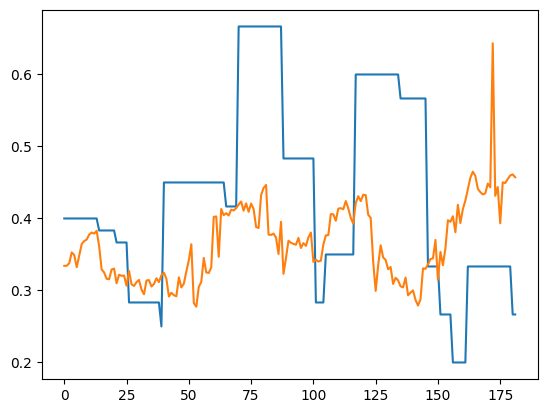

In [17]:
plt.plot(y_all,)
plt.plot(y_pred_all)

In [44]:
xs, ys = [], []
for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    xs.append(x) 
    ys.append(y)

In [46]:
x = xs[-3]

In [109]:
import importlib
importlib.reload(interp)

<module 'src.utils.interpretability' from '/root/autodl-tmp/chuandian_eq/src/utils/interpretability.py'>

In [126]:
# Token Importance: unified compute function
scores, label = interp.compute_token_importance(model, x, method='ig', n_steps=300,signed=True)

In [119]:
from  src.utils.mask_utils import get_non_pad_mask
mask = get_non_pad_mask(x[:,:,0]).squeeze(-1).cpu().numpy()

In [ ]:
sample_idx = 14

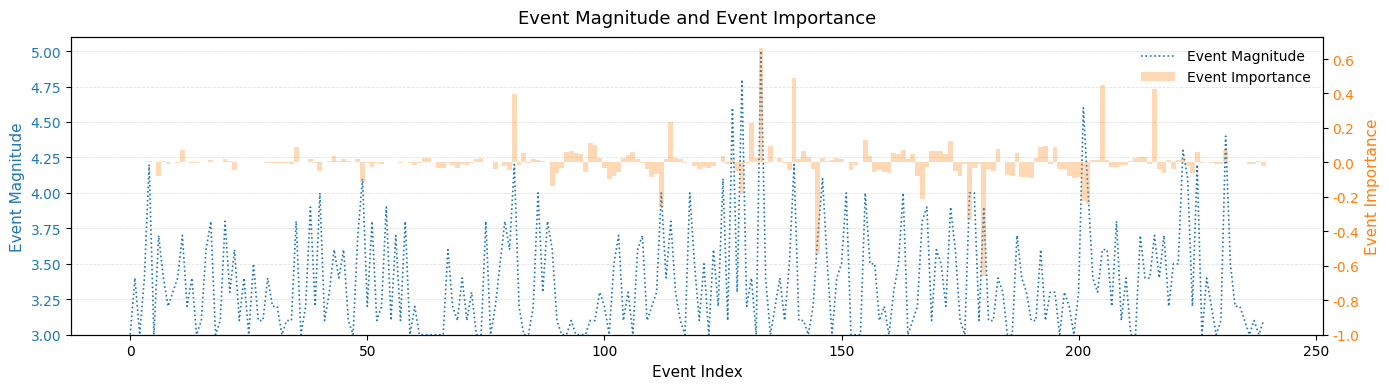

In [125]:
fig, ax_mag, ax_imp = interp.plot_magnitude_and_importance(
    x=x,
    scores=scores,
    sample_idx=sample_idx,
    feature_idx=2,
    mask=mask,        
    min_magnitude=3,
    min_importance=-1
)


In [122]:
# Build a valid token mask (True = token has non-zero features)
valid_mask = (x[sample_idx].abs().sum(dim=-1) > 0)

# Rank tokens
ranks = interp.rank_tokens_numeric(token_scores=scores, sample_idx=sample_idx, valid_mask=valid_mask, topn=20)
print("Top tokens by importance (index, score):")
for i, (idx, sc) in enumerate(ranks['top'], 1):
    print(f"{i:>2}. idx={idx:<3} score={sc:.6f}")

# Deletion validation with zeroing tokens
validation = interp.deletion_validation_numeric(
    model=model,
    x=x,
    token_scores=scores,
    sample_idx=sample_idx,
    topk_list=(1, 2, 5, 10),
    deletion_mode='zero',            # alternatives: 'baseline', 'noise'
    baseline_strategy='zeros',       # used only when deletion_mode='baseline'
    valid_mask=valid_mask,
    return_details=True,
)

print(f"Baseline prediction: {validation['baseline']:.6f}")
print("Top-k deletion drops:")
for r in validation['results']['topk']:
    print(f"k={r['k']:>2} drop={r['drop']:.6f}")

print("Least-k deletion drops (sanity):")
for r in validation['results']['leastk']:
    print(f"k={r['k']:>2} drop={r['drop']:.6f}")


Top tokens by importance (index, score):
 1. idx=198 score=0.888163
 2. idx=168 score=0.623709
 3. idx=240 score=0.597429
 4. idx=166 score=0.533481
 5. idx=116 score=0.532851
 6. idx=251 score=0.527349
 7. idx=190 score=0.467918
 8. idx=132 score=0.344306
 9. idx=149 score=0.327436
10. idx=133 score=0.326182
11. idx=129 score=0.241618
12. idx=130 score=0.240549
13. idx=175 score=0.235967
14. idx=128 score=0.225965
15. idx=177 score=0.224324
16. idx=208 score=0.221412
17. idx=170 score=0.191989
18. idx=120 score=0.173578
19. idx=200 score=0.171946
20. idx=141 score=0.167938
Baseline prediction: 0.399240
Top-k deletion drops:
k= 1 drop=0.092921
k= 2 drop=0.065637
k= 5 drop=0.064792
k=10 drop=0.001113
Least-k deletion drops (sanity):
k= 1 drop=0.000000
k= 2 drop=0.000000
k= 5 drop=0.000000
k=10 drop=0.000000
